In [2]:
# !pip install XGBoost
import numpy as np


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
df = pd.read_csv("C:\\Users\\HARSH GOSALIA\\Downloads\\retail_sales_bigmart.csv")
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='str')

In [5]:
df.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,DRC66,5.242170,low fat,0.064002,Dairy,121.71,OUT045,2002,NaN,Tier 2,Supermarket Type1,2419.82
1,DUS55,NaN,LF,0.042572,Snack Foods,203.31,OUT046,2013,Small,Tier 1,Supermarket Type1,2259.98
2,DUJ83,21.058597,Low Fat,0.068903,Snack Foods,237.89,OUT013,1987,High,Tier 3,Supermarket Type1,5870.58
3,DUN02,7.276768,LF,0.038148,Soft Drinks,206.00,OUT013,1987,High,Tier 3,Supermarket Type1,4661.53
4,NCW27,17.113985,reg,0.040903,Breakfast,246.30,OUT018,2009,Medium,Tier 3,Supermarket Type2,3059.90


In [6]:
df.shape

(16000, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            16000 non-null  str    
 1   Item_Weight                14414 non-null  float64
 2   Item_Fat_Content           16000 non-null  str    
 3   Item_Visibility            16000 non-null  float64
 4   Item_Type                  16000 non-null  str    
 5   Item_MRP                   16000 non-null  float64
 6   Outlet_Identifier          16000 non-null  str    
 7   Outlet_Establishment_Year  16000 non-null  int64  
 8   Outlet_Size                11861 non-null  str    
 9   Outlet_Location_Type       16000 non-null  str    
 10  Outlet_Type                16000 non-null  str    
 11  Item_Outlet_Sales          16000 non-null  float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.5 MB


In [8]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1586
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4139
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [9]:
Categorial_columns = df.select_dtypes(include='str').columns
print("Categorial features:")
print(Categorial_columns)

Categorial features:
Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='str')


In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns
print("Numeric features:")  
numeric_columns

Numeric features:


Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='str')

In [11]:
Categorial_columns.isnull().sum()

np.int64(0)

In [12]:
numeric_columns.isnull().sum()

np.int64(0)

In [13]:
#mean value of item weight column

item_mean = df['Item_Weight'].mean()
print(item_mean)

14.91794454934087


In [14]:
print(df['Item_Weight'].isnull().sum())

df['Item_Weight'] = df['Item_Weight'].fillna(item_mean)
print(df.isnull().sum())

1586
Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4139
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


Outlet_Size => Useing Mode bcz -> it is a categorical feature, and mode replaces missing values with the most frequent category in the dataset.

- Outlet_Size is a categorical variable (e.g., Small, Medium, High).

- For categorical data, we cannot use mean or median.

- The best way to fill missing values is the mode, which is the most frequent category in the column.


In [15]:
df['Outlet_Size'].value_counts()

Outlet_Size
Small     4953
Medium    4355
High      1347
SMALL      294
medium     270
MED        252
small      246
Large       74
HIGH        70
Name: count, dtype: int64

In [16]:
df['Outlet_Type'].value_counts()

Outlet_Type
Supermarket Type1    9902
Grocery Store        2589
Supermarket Type3    1901
Supermarket Type2    1608
Name: count, dtype: int64

In [17]:
mode_of_outlet_size = df.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=lambda x: x.mode().iloc[0])
mode_of_outlet_size

# OR
# df.groupby('Outlet_Type')['Outlet_Size'].apply(lambda x: x.mode()[0])

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [18]:
print(df['Outlet_Size'].isnull().sum())

missing_values = df['Outlet_Size'].isnull()

missing_values

4139


0         True
1        False
2        False
3        False
4        False
         ...  
15995    False
15996    False
15997    False
15998    False
15999    False
Name: Outlet_Size, Length: 16000, dtype: bool

In [19]:
df.loc[missing_values,'Outlet_Size'] = df.loc[missing_values,'Outlet_Type'].apply(lambda x: mode_of_outlet_size[x])

In [20]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

# Data Analysis


In [21]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,14.917945,0.053566,211.208082,1999.100062,3728.604334
std,5.483306,0.065455,77.293193,9.691996,2446.002607
min,5.000233,0.000000,55.850000,1985.000000,30.000000
25%,10.441255,0.024868,152.315000,1987.000000,2039.647500
50%,14.917945,0.043975,198.855000,2002.000000,3148.625000
75%,19.351410,0.068110,259.097500,2007.000000,4759.047500
max,24.998497,0.897160,499.900000,2013.000000,27232.780000


Numeric Feature


In [22]:
sns.set()

<Figure size 600x600 with 0 Axes>

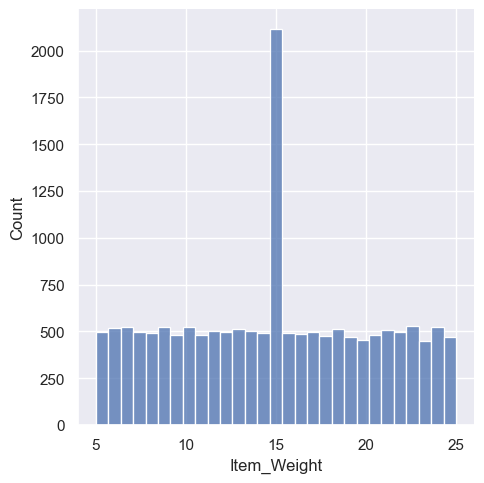

In [23]:
plt.figure(figsize=(6,6))
sns.displot(df['Item_Weight'])
plt.show()

<Figure size 600x600 with 0 Axes>

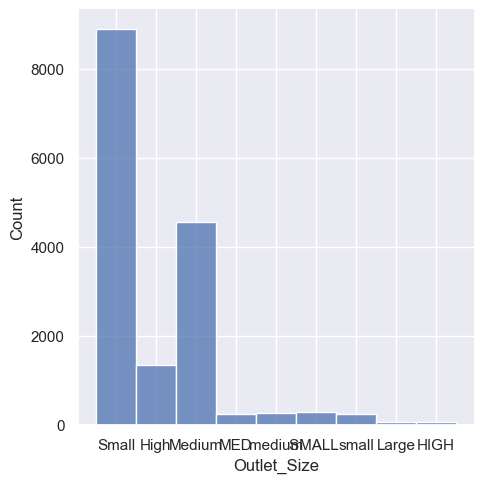

In [24]:
plt.figure(figsize=(6,6))
sns.displot(df['Outlet_Size'])
plt.show()

<Figure size 600x600 with 0 Axes>

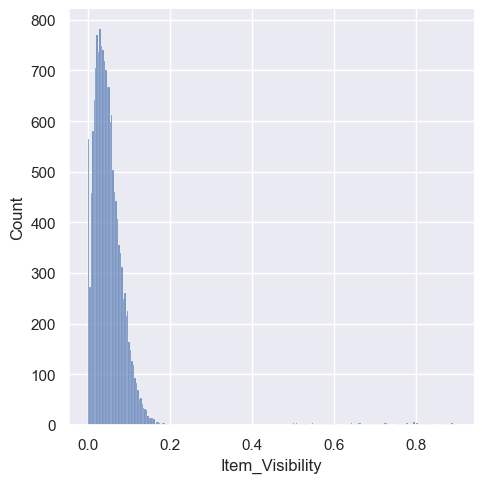

In [25]:
plt.figure(figsize=(6,6))
sns.displot(df['Item_Visibility'])
plt.show()

<Figure size 600x600 with 0 Axes>

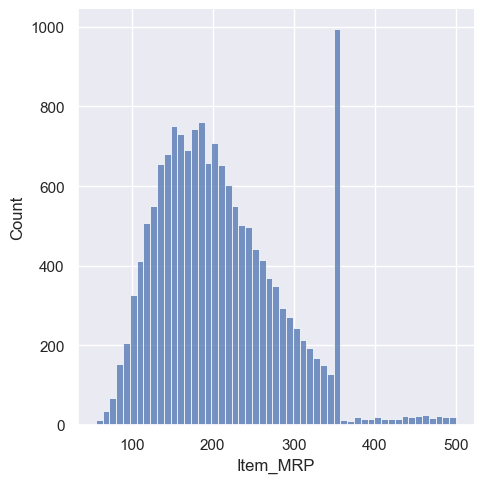

In [26]:
plt.figure(figsize=(6,6))
sns.displot(df['Item_MRP'])
plt.show()

<Figure size 600x600 with 0 Axes>

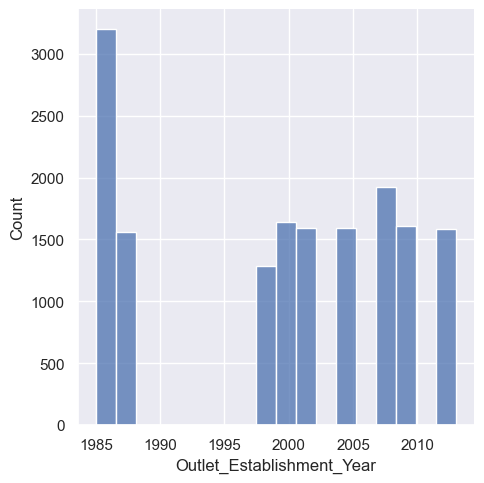

In [27]:
plt.figure(figsize=(6,6))
sns.displot(df['Outlet_Establishment_Year'])
plt.show()

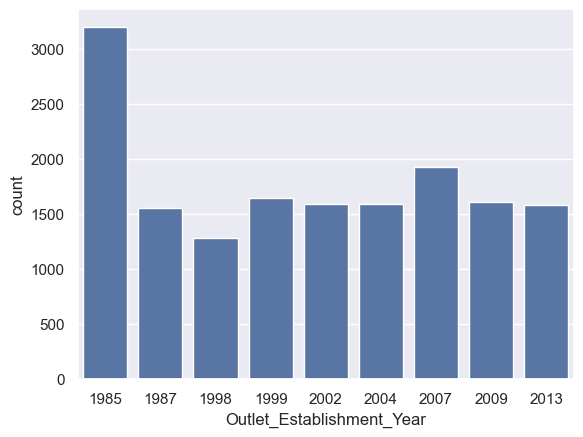

In [28]:
sns.countplot(x='Outlet_Establishment_Year', data=df)
plt.show()

now, check categorical data colums


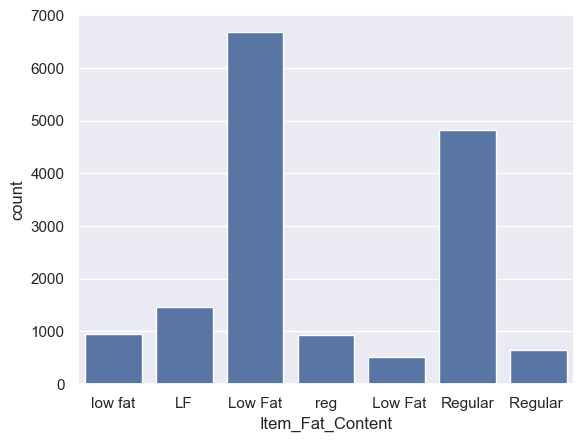

In [29]:
sns.countplot(x='Item_Fat_Content', data=df)
plt.show()

In [30]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,DRC66,5.242170,low fat,0.064002,Dairy,121.71,OUT045,2002,Small,Tier 2,Supermarket Type1,2419.82
1,DUS55,14.917945,LF,0.042572,Snack Foods,203.31,OUT046,2013,Small,Tier 1,Supermarket Type1,2259.98
2,DUJ83,21.058597,Low Fat,0.068903,Snack Foods,237.89,OUT013,1987,High,Tier 3,Supermarket Type1,5870.58
3,DUN02,7.276768,LF,0.038148,Soft Drinks,206.00,OUT013,1987,High,Tier 3,Supermarket Type1,4661.53
4,NCW27,17.113985,reg,0.040903,Breakfast,246.30,OUT018,2009,Medium,Tier 3,Supermarket Type2,3059.90
...,...,...,...,...,...,...,...,...,...,...,...,...
15995,DRC12,17.233114,low fat,0.010963,Hard Drinks,199.25,OUT013,1987,High,Tier 3,Supermarket Type1,5885.54
15996,NCW46,10.174233,Regular,0.052483,Soft Drinks,289.15,OUT013,1987,High,Tier 3,Supermarket Type1,4847.83
15997,DUN71,10.959149,low fat,0.014597,Breakfast,101.59,OUT035,2004,Small,Tier 2,Supermarket Type1,1621.67
15998,NCL16,16.209470,Low Fat,0.053749,Fruits and Vegetables,219.90,OUT049,1999,Medium,Tier 1,Supermarket Type1,3519.60


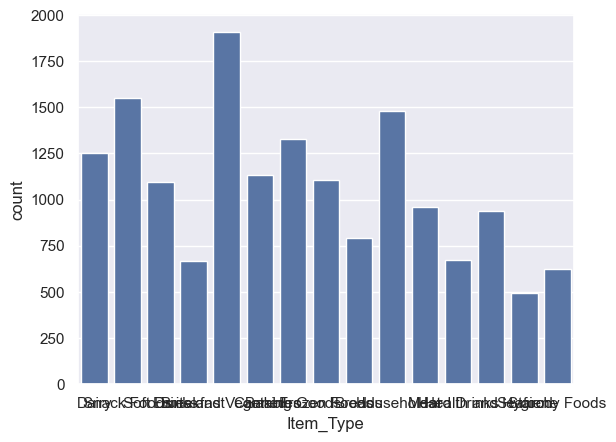

In [31]:

sns.countplot(x='Item_Type',data=df)
plt.show()
                               

# Data Preprocessing


In [32]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,DRC66,5.242170,low fat,0.064002,Dairy,121.71,OUT045,2002,Small,Tier 2,Supermarket Type1,2419.82
1,DUS55,14.917945,LF,0.042572,Snack Foods,203.31,OUT046,2013,Small,Tier 1,Supermarket Type1,2259.98
2,DUJ83,21.058597,Low Fat,0.068903,Snack Foods,237.89,OUT013,1987,High,Tier 3,Supermarket Type1,5870.58
3,DUN02,7.276768,LF,0.038148,Soft Drinks,206.00,OUT013,1987,High,Tier 3,Supermarket Type1,4661.53
4,NCW27,17.113985,reg,0.040903,Breakfast,246.30,OUT018,2009,Medium,Tier 3,Supermarket Type2,3059.90


In [33]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat     6686
Regular     4816
LF          1457
low fat      952
reg          928
Regular      642
 Low Fat     519
Name: count, dtype: int64

In [34]:
df = df.replace({'low fat' : 'Low Fat', 'LF' : 'Low Fat', 'reg' : 'Regular', ' Low Fat' : 'Low Fat' },inplace=True)
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat     9614
Regular     5744
Regular      642
Name: count, dtype: int64

In [35]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,DRC66,5.242170,Low Fat,0.064002,Dairy,121.71,OUT045,2002,Small,Tier 2,Supermarket Type1,2419.82
1,DUS55,14.917945,Low Fat,0.042572,Snack Foods,203.31,OUT046,2013,Small,Tier 1,Supermarket Type1,2259.98
2,DUJ83,21.058597,Low Fat,0.068903,Snack Foods,237.89,OUT013,1987,High,Tier 3,Supermarket Type1,5870.58
3,DUN02,7.276768,Low Fat,0.038148,Soft Drinks,206.00,OUT013,1987,High,Tier 3,Supermarket Type1,4661.53
4,NCW27,17.113985,Regular,0.040903,Breakfast,246.30,OUT018,2009,Medium,Tier 3,Supermarket Type2,3059.90
...,...,...,...,...,...,...,...,...,...,...,...,...
15995,DRC12,17.233114,Low Fat,0.010963,Hard Drinks,199.25,OUT013,1987,High,Tier 3,Supermarket Type1,5885.54
15996,NCW46,10.174233,Regular,0.052483,Soft Drinks,289.15,OUT013,1987,High,Tier 3,Supermarket Type1,4847.83
15997,DUN71,10.959149,Low Fat,0.014597,Breakfast,101.59,OUT035,2004,Small,Tier 2,Supermarket Type1,1621.67
15998,NCL16,16.209470,Low Fat,0.053749,Fruits and Vegetables,219.90,OUT049,1999,Medium,Tier 1,Supermarket Type1,3519.60


In [36]:
le = LabelEncoder()

LabelEncoding for all categorical data


In [37]:
df['Item_Identifier'] = le.fit_transform(df['Item_Identifier'])
df['Item_Identifier']

0         132
1        2371
2        1898
3        2076
4        5353
         ... 
15995     109
15996    5365
15997    2112
15998    4707
15999    1292
Name: Item_Identifier, Length: 16000, dtype: int64

In [38]:
for i in Categorial_columns:
    df[i] = le.fit_transform(df[i])

In [39]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,132,5.242170,0,0.064002,4,121.71,7,2002,6,1,1,2419.82
1,2371,14.917945,0,0.042572,12,203.31,8,2013,6,0,1,2259.98
2,1898,21.058597,0,0.068903,12,237.89,1,1987,1,2,1,5870.58
3,2076,7.276768,0,0.038148,13,206.00,1,1987,1,2,1,4661.53
4,5353,17.113985,1,0.040903,2,246.30,3,2009,4,2,2,3059.90
...,...,...,...,...,...,...,...,...,...,...,...,...
15995,109,17.233114,0,0.010963,7,199.25,1,1987,1,2,1,5885.54
15996,5365,10.174233,1,0.052483,13,289.15,1,1987,1,2,1,4847.83
15997,2112,10.959149,0,0.014597,2,101.59,6,2004,6,1,1,1621.67
15998,4707,16.209470,0,0.053749,6,219.90,9,1999,4,0,1,3519.60


In [40]:
X = df.drop(columns='Item_Outlet_Sales')
y = df['Item_Outlet_Sales']



In [41]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X.shape, X_train.shape, X_test.shape)

(16000, 11) (12800, 11) (3200, 11)


# XGBoost Regressor


In [42]:
regressor = XGBRegressor()
regressor.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [43]:
y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 1816138.6832745397
R^2 Score: 0.7004423595225564


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=7
)

model.fit(X_train, y_train)
pred = model.predict(X_test)
score = r2_score(y_test, pred)

print("Model Accuracy (R2 Score):", score)

Model Accuracy (R2 Score): 0.711906761201065


In [45]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,132,5.242170,0,0.064002,4,121.71,7,2002,6,1,1,2419.82
1,2371,14.917945,0,0.042572,12,203.31,8,2013,6,0,1,2259.98
2,1898,21.058597,0,0.068903,12,237.89,1,1987,1,2,1,5870.58
3,2076,7.276768,0,0.038148,13,206.00,1,1987,1,2,1,4661.53
4,5353,17.113985,1,0.040903,2,246.30,3,2009,4,2,2,3059.90
...,...,...,...,...,...,...,...,...,...,...,...,...
15995,109,17.233114,0,0.010963,7,199.25,1,1987,1,2,1,5885.54
15996,5365,10.174233,1,0.052483,13,289.15,1,1987,1,2,1,4847.83
15997,2112,10.959149,0,0.014597,2,101.59,6,2004,6,1,1,1621.67
15998,4707,16.209470,0,0.053749,6,219.90,9,1999,4,0,1,3519.60


# Random Forest


In [46]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

score = r2_score(y_test, pred)
print("Model Accuracy (R2 Score):", score)

Model Accuracy (R2 Score): 0.7136290294980405


# Linear Regression


In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
score = r2_score(y_test, pred)
print("Model Accuracy (R2 Score):", score)

Model Accuracy (R2 Score): 0.6012404894510444


# Decision Tree


In [48]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

model = DecisionTreeRegressor()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.4834985635394421


# Support Vector Machine (SVM) => SVR


In [49]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score

model = SVR(kernel='rbf')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.06232839915176602


In [50]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Base Models

base_models = [
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=200)),
    ('xgb', XGBRegressor(n_estimators=200))
]

# Meta Model
meta_model = Ridge()

# Stacking Model
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model
)

# Train
stack_model.fit(X_train, y_train)

# Predict
y_pred = stack_model.predict(X_test)

from sklearn.metrics import r2_score

print("Stacking Model R2 Score:", r2_score(y_test, y_pred))

Stacking Model R2 Score: 0.7373735384494824


In [51]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

# X_train, X_test, y_train, y_test already banaya hoga

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

# XGBoost alag import
from xgboost import XGBRegressor
models["XGBoost"] = XGBRegressor()

# Training + Evaluation
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    print(f"{name}: {score:.4f}")

Linear: 0.6012
Ridge: 0.6012
Lasso: 0.6015
Decision Tree: 0.4732
Random Forest: 0.7028
Gradient Boosting: 0.7349
KNN: 0.0041
SVR: -0.0623
XGBoost: 0.7004


In [52]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# Base models
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor()),
    ('dt', DecisionTreeRegressor()),
    ('xgb', XGBRegressor())
]

# Meta model (final learner)
meta_model = LinearRegression()

# Stacking Regressor
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

# Train
stack_model.fit(X_train, y_train)

# Predict
y_pred = stack_model.predict(X_test)

# Evaluate
score = r2_score(y_test, y_pred)
print("Stacking R2 Score:", score)

Stacking R2 Score: 0.735871463935597


In [53]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Base model (weak learner)
base_model = DecisionTreeRegressor()

# Bagging model
bag_model = BaggingRegressor(
    estimator=base_model,
    n_estimators=50,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

# Train
bag_model.fit(X_train, y_train)

# Predict
y_pred = bag_model.predict(X_test)

# Evaluate
score = r2_score(y_test, y_pred)
print("Bagging R2 Score:", score)

Bagging R2 Score: 0.6999544820167406


In [54]:
from sklearn.metrics import r2_score, mean_absolute_error,  mean_squared_error, root_mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))


R2 Score: 0.6999544820167406
MAE: 913.2726123125001
MSE: 1819096.5554543287
RMSE: 1348.7388759334879


In [55]:
import pandas as pd
import numpy as np

# Ensure X_train and stack_model exist
if 'X_train' not in globals():
    raise NameError("X_train not found in the environment. Run training/splitting first.")
if 'stack_model' not in globals():
    raise NameError("stack_model not found. Train or load your model first.")

# Create empty dataframe with same columns and one zero row
input_df = pd.DataFrame(columns=X_train.columns).astype(float)
input_df.loc[0] = 0.0

# ===== USER INPUT VALUES =====
item_weight = 80
item_mrp = 300
visibility_ratio = 1.4
outlet_age = 30

outlet_size = 'High'
mrp_level = 'Medium'
item_fat = 'Low Fat'
outlet_location = 'Tier 1'
outlet_type = 'Supermarket Type1'
item_category = 'FD'

# ===== Feature Engineering =====
price_per_weight = item_mrp / (item_weight if item_weight != 0 else 1e-6)
outlet_type_size = f"{outlet_type}_{outlet_size}"

# Helper to set column if present
def set_col(col, value):
    if col in input_df.columns:
        input_df.at[0, col] = value

# ===== Fill numeric =====
set_col('Item_Weight', item_weight)
set_col('Item_MRP', item_mrp)
set_col('Price_per_Weight', price_per_weight)
set_col('Visibility_Ratio', visibility_ratio)
set_col('Outlet_Age', outlet_age)

# ===== Ordinal Encoding (safe) =====
size_map = {'Small': 0, 'Medium': 1, 'High': 2}
mrp_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}

if 'Outlet_Size' in input_df.columns:
    input_df.at[0, 'Outlet_Size'] = size_map.get(outlet_size, np.nan)

if 'MRP_Level' in input_df.columns:
    input_df.at[0, 'MRP_Level'] = mrp_map.get(mrp_level, np.nan)

# ===== Categorical handling: prefer one-hot when present, else set raw categorical if feature is object-type in X_train =====
# One-hot column names used earlier in your notebook
one_hot_cols = [
    f"Item_Fat_Content_{item_fat}",
    f"Outlet_Location_Type_{outlet_location}",
    f"Outlet_Type_{outlet_type}",
    f"Item_Category_{item_category}",
    f"Outlet_Type_Size_{outlet_type_size}"
]

# Set one-hot flags if those columns exist
for col in one_hot_cols:
    if col in input_df.columns:
        input_df.at[0, col] = 1.0

# If the dataset used label-encoded categorical columns (e.g., 'Item_Fat_Content' stored as strings),
# set the raw string value only when X_train kept object dtype for that column.
for raw_col, raw_value in [
    ('Item_Fat_Content', item_fat),
    ('Outlet_Location_Type', outlet_location),
    ('Outlet_Type', outlet_type),
    ('Item_Category', item_category),
    ('Outlet_Type_Size', outlet_type_size)
]:
    if raw_col in input_df.columns:
        # if the training X_train kept this column as object/string, set the string; otherwise skip
        if X_train[raw_col].dtype == object or X_train[raw_col].dtype == 'O':
            input_df.at[0, raw_col] = raw_value

# Final safety: ensure dtype numeric for prediction (convert where possible)
for c in input_df.columns:
    try:
        input_df[c] = pd.to_numeric(input_df[c], errors='coerce')
    except Exception:
        pass

# Replace any remaining NaNs with 0 (or choose a different policy)
input_df = input_df.fillna(0.0)

# ===== Prediction =====
try:
    prediction = stack_model.predict(input_df)
    print("Predicted Sales:", round(float(prediction[0]), 2))
except Exception as e:
    print("Prediction failed:", str(e))
    # Helpful debug info
    print("Input shape:", input_df.shape)
    print("Missing columns compared to X_train:", list(set(X_train.columns) - set(input_df.columns)))
    raise

Predicted Sales: 2742.15


In [61]:
import pandas as pd
import numpy as np

# Ensure required objects exist
if 'X_train' not in globals():
    raise NameError("X_train not found.")

if 'stack_model' not in globals():
    raise NameError("stack_model not found.")

# Create input dataframe
input_df = pd.DataFrame(columns=X_train.columns)
input_df.loc[0] = 0


# ---------- INPUT FUNCTIONS ----------
def get_float(prompt, min_val=None):
    while True:
        try:
            val = float(input(prompt))
            if min_val is not None and val <= min_val:
                print(f"Enter value > {min_val}")
                continue
            return val
        except:
            print("Enter valid number!")


def get_int(prompt):
    while True:
        s = input(prompt)
        if s.isdigit():
            return int(s)
        print("Enter valid integer!")


def get_choice_numeric(prompt, options):
    while True:
        print("\n" + prompt)
        for k, v in options.items():
            print(f"{k}: {v}")

        choice = input("Enter choice: ")

        if choice.isdigit():
            choice = int(choice)
            if choice in options:
                return choice, options[choice]

        print("Invalid choice!")


# ---------- USER INPUT ----------
print("\n===== ENTER PRODUCT DETAILS =====")

item_weight = get_float("Item Weight (>0): ", 0)
item_mrp = get_float("Item MRP (>0): ", 0)
visibility_ratio = get_float("Visibility Ratio: ")
outlet_age = get_int("Outlet Age: ")

# 👇 Now user enters 1,2,3 directly
outlet_size_val, outlet_size = get_choice_numeric("Outlet Size", {
    1: 'Small',
    2: 'Medium',
    3: 'High'
})

mrp_level_val, mrp_level = get_choice_numeric("MRP Level", {
    1: 'Low',
    2: 'Medium',
    3: 'High',
    4: 'Very High'
})

item_fat_val, item_fat = get_choice_numeric("Fat Content", {
    1: 'Low Fat',
    2: 'Regular'
})

outlet_location_val, outlet_location = get_choice_numeric("Location", {
    1: 'Tier 1',
    2: 'Tier 2',
    3: 'Tier 3'
})

outlet_type_val, outlet_type = get_choice_numeric("Outlet Type", {
    1: 'Supermarket Type1',
    2: 'Supermarket Type2',
    3: 'Supermarket Type3'
})

item_category_val, item_category = get_choice_numeric("Item Category", {
    1: 'DR',
    2: 'DU',
    3: 'NC'
})


# ---------- FEATURE ENGINEERING ----------
price_per_weight = item_mrp / item_weight
outlet_type_size = f"{outlet_type}_{outlet_size}"


# ---------- SET VALUES ----------
def set_col(col, val):
    if col in input_df.columns:
        input_df.at[0, col] = val


# Numeric
set_col('Item_Weight', item_weight)
set_col('Item_MRP', item_mrp)
set_col('Price_per_Weight', price_per_weight)
set_col('Visibility_Ratio', visibility_ratio)
set_col('Outlet_Age', outlet_age)

# 👇 DIRECT 1,2,3 encoding
set_col('Outlet_Size', outlet_size_val)
set_col('MRP_Level', mrp_level_val)


# ---------- ONE HOT ----------
one_hot_cols = [
    f'Item_Fat_Content_{item_fat}',
    f'Outlet_Location_Type_{outlet_location}',
    f'Outlet_Type_{outlet_type}',
    f'Item_Category_{item_category}',
    f'Outlet_Type_Size_{outlet_type_size}'
]

for col in one_hot_cols:
    if col in input_df.columns:
        input_df.at[0, col] = 1


# ---------- FINAL ----------
input_df = input_df.fillna(0)
input_df = input_df.reindex(columns=X_train.columns, fill_value=0)


# ---------- PREDICTION ----------
try:
    pred = stack_model.predict(input_df)

    print("\n===================================")
    print(f"🛒 Predicted Sales: ₹{pred[0]:.2f}")
    print("===================================")

except Exception as e:
    print("Prediction failed:", e)
    print(input_df.head())


===== ENTER PRODUCT DETAILS =====



Outlet Size
1: Small
2: Medium
3: High

MRP Level
1: Low
2: Medium
3: High
4: Very High

Fat Content
1: Low Fat
2: Regular

Location
1: Tier 1
2: Tier 2
3: Tier 3

Outlet Type
1: Supermarket Type1
2: Supermarket Type2
3: Supermarket Type3

Item Category
1: DR
2: DU
3: NC

🛒 Predicted Sales: ₹2411.93
